# S4 Optional: Detecting Laundering Rings with a Graph Neural Network

Anti-money-laundering (AML) surveillance is one of the canonical industry use cases for graph machine learning. A laundering ring is a small cluster of accounts that move funds among themselves in cyclic or layered patterns; from any one account's row in a transaction CSV the pattern is invisible, but as a subgraph it is the same kind of community structure a graph neural network (GNN) detects on a citation network or a karate club. In this optional example, we generate a small synthetic AML transaction graph, train a three-layer GNN to flag accounts that sit inside a planted laundering ring, and contrast the result against a flat features-only baseline.

The framing question for this notebook: **can we identify accounts inside a laundering ring from local transfer-graph structure alone, when per-account summary features overlap heavily across the two classes?**

The model architecture follows the __GraphSAGE__ (SAmple and aggreGatE) self-plus-neighbor split of [Hamilton, Ying, and Leskovec (2017)](https://arxiv.org/abs/1706.02216), with the normalized variant of [Kipf and Welling (2017)](https://arxiv.org/abs/1609.02907) as the closely related reference. We use the layer for __node__ classification: each node carries its own ring / non-ring label and the readout is per-node logits.

> __Learning Objectives:__
>
> By the end of this example, we will be able to:
>
> * __Frame node classification on a transaction graph:__ Identify when money-laundering detection is naturally a graph problem and read the GNN's three inputs (the adjacency matrix $\mathbf{A}$, the per-node feature matrix $\mathbf{X}$, and the partial label vector $\mathbf{y}$) in their AML-specific roles. Recognize why the network trains on labeled nodes only while every node's features and edges still flow through message passing.
> * __Train an imbalanced GNN node classifier:__ Build a three-layer GraphSAGE-style stack with a per-node logits head, train with class-weighted cross-entropy, and read the resulting precision / recall / F1 scorecard for the minority (laundering-ring) class. Recognize why F1 is the metric that matters when only a small fraction of accounts are positives.
> * __Quantify the value of graph structure:__ Compare the GNN against a feature-only multi-layer perceptron (MLP) trained on the same node features and explain why a classifier that ignores edges has to fall back on noisy summary statistics alone.

A naming note: the shared `code/src/` package was written with generic `fraud_*` identifiers (`simulate_fraud_graph`, `MyFraudGNNLayer`, `evaluate_fraud_classifier`, and so on); we keep those names in the code cells for compatibility, while the prose below uses the precise AML vocabulary (laundering ring, ring member, ring / non-ring labels).

Let's get to it!
___

## Background: Graph Neural Networks

We sit at the intersection of two topics: graph machine learning and the structural fingerprint of money laundering in payments data. Before generating the synthetic transaction graph and training a classifier, we summarise what a graph neural network does and what we are looking for inside a transaction graph that contains laundering activity.

An input graph (left) with each node $i$ carrying a feature vector $\mathbf{x}_{i}$ enters a stack of $L$ message-passing layers (the schematic shows $L = 2$ for clarity; we use $L = 3$ in this notebook). We call $\mathbf{h}_{i}^{(\ell)} \in \mathbb{R}^{d_{\ell}}$ the __state__ of node $i$ at layer $\ell$: a length-$d_{\ell}$ vector that summarises node $i$'s identity together with the neighborhood it can see in $\ell$ hops. The initial state is $\mathbf{h}_{i}^{(0)} = \mathbf{x}_{i}$; each subsequent layer rewrites it by mixing the node's current state with its neighbors'. The readout on the right applies a per-node head to the final state $\mathbf{h}_{i}^{(L)}$ and emits one prediction per account (ring / non-ring).

<div>
    <center>
        <img src="figs/gnn-schematic.svg" width="950" alt="GNN message-passing schematic: input graph, stacked GNN layers updating node states by aggregating from neighbors, and a readout that emits per-node predictions."/>
    </center>
</div>

__Why graph neural networks?__ A multi-layer perceptron (MLP) operates on a fixed-length vector; a recurrent network on a sequence of fixed length. A transaction graph has neither shape: the number of accounts changes from one bank to the next, the number of counterparties per account varies, and there is no natural ordering of an account's neighbors. A GNN is designed for exactly this input.

We use the __GraphSAGE__ self-plus-neighbor update of [Hamilton, Ying, and Leskovec (2017)](https://arxiv.org/abs/1706.02216). With per-layer weight matrices $\mathbf{W}_{1}^{(\ell)}, \mathbf{W}_{2}^{(\ell)} \in \mathbb{R}^{d_{\ell + 1} \times d_{\ell}}$ and bias $\mathbf{b}^{(\ell)} \in \mathbb{R}^{d_{\ell + 1}}$, each layer updates the node state as:

$$
\mathbf{h}_{i}^{(\ell + 1)} = \sigma\!\left(\mathbf{W}_{1}^{(\ell)}\,\mathbf{h}_{i}^{(\ell)} \;+\; \mathbf{W}_{2}^{(\ell)}\sum_{j\in\mathcal{N}(i)}\mathbf{h}_{j}^{(\ell)} \;+\; \mathbf{b}^{(\ell)}\right),
$$

where $\sigma$ is an elementwise nonlinearity (we use ReLU) and $\mathcal{N}(i)$ is the set of accounts that transact with node $i$. The first term keeps each node's own signal; the second injects an unweighted sum over its neighbors'. Only the per-layer weights $\mathbf{W}_{1}^{(\ell)}, \mathbf{W}_{2}^{(\ell)}, \mathbf{b}^{(\ell)}$ are learned, and the same weights update every node at layer $\ell$ (so the parameter count is independent of the number of accounts).

Stacking is how distant information reaches a node: one layer reaches direct counterparties, two layers reach counterparties of counterparties. Past three or four layers, every node's state blurs toward the same limit (an effect called __oversmoothing__); we use $L = 3$.

___

### What money laundering looks like in a transaction graph

A transaction graph has accounts as nodes and transfers as directed edges from sender to recipient. Most accounts are legitimate, and their connection pattern is approximately random: a few counterparties scattered across the population, no particular community structure. Money laundering activity leaves a different fingerprint.

The figure below shows six recurring AML patterns. This notebook plants only the first two (ring and chord); the other four (layering chains, mule accounts, smurfing, fan-in / fan-out) are cataloged here for context and do not appear in the synthetic graph we train on.

<div>
    <center>
        <img src="figs/Fig-AMLPatterns.svg" width="950" alt="Six money-laundering patterns drawn as small transaction sub-graphs: a directed ring cycle; a densified ring with chord edges; a layering chain through mule intermediaries; a single mule routing transfers between legitimate counterparties; a smurfing pattern that splits one transfer into many small below-threshold transfers; and a fan-in / fan-out pattern showing a single account with unusually many counterparties."/>
    </center>
</div>

> __The two patterns we plant:__
>
> * __Ring (cycle):__ A closed loop of accounts that move funds among themselves: A pays B, B pays C, C pays A. After a full circuit the original balances are largely restored, but the audit trail now shows three transfers across three accounts instead of one. Rings leave one of the cleanest structural signatures: a cycle in the transaction graph.
> * __Chord (densified ring):__ A ring whose members also transact pairwise outside the basic cycle, so each laundering account sits in a small, dense subgroup that all transacts together. This is what we plant in this notebook: every laundering account sits in a ring of three to seven members that share a guaranteed cycle plus random chord edges between them.

A GNN sees both patterns because message passing aggregates each node's neighbors and the neighbors of its neighbors: a ring shows up as a tight cyclic neighborhood that legitimate accounts do not have.

__The synthetic graph plants rings only.__ Every laundering account belongs to a ring of three to seven members, with chord edges added at random between them. We then add an __Erdős–Rényi__ random-graph background: every pair of accounts gets a directed edge independently with probability `P_LEGIT_EDGE`, so each ring member also transacts with the legitimate population and the planted ring is buried inside the random-graph noise rather than being a disconnected component. The per-node features (in-volume, out-volume, counterparty count, average amount, account age, and a geographic hash) are deliberately drawn from the same distribution for ring and non-ring accounts, so the only signal that distinguishes the two classes is local graph structure. This is what motivates the closing comparison against a feature-only MLP.

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [1]:
include("Include.jl");

### Constants
In the section below, we set the constants used throughout the notebook. Modify these to explore different graph sizes, ring fractions, or feature-noise levels.

* __Synthetic Graphs__: We fix the synthetic-graph generator parameters and the GNN training hyperparameters below. Larger `N_ACCOUNTS` and tighter `FEATURE_NOISE` sharpen the structural signal; smaller `RING_FRACTION` makes the imbalance harder. The defaults are tuned so the GNN reaches high F1 on the laundering-ring class while the flat-MLP baseline lands well below it, making the value-of-graph-structure comparison in Task 3 clear.

See the inline comments for units and roles.

In [2]:
# --- Generator knobs ---
N_ACCOUNTS::Int       = 1000;        # total nodes in the transaction graph
RING_FRACTION::Float64 = 0.16;      # fraction of accounts planted in a ring (~160 of 1000)
RING_SIZE_RANGE       = 8:14;       # uniform draw on the size of each planted ring
P_LEGIT_EDGE::Float64  = 0.009;     # Erdős–Rényi prob for a directed edge between two legit accounts
FEATURE_NOISE::Float64 = 0.5;       # Gaussian-noise multiplier on the volume / amount features
TRAIN_FRAC::Float64    = 0.7;       # stratified train fraction within each class
MASTER_SEED::Int       = 11;        # RNG seed; fixes ring placement, edges, features, and masks

# --- Model knobs ---
N_HIDDEN::Int        = 32;          # hidden width shared across the three message-passing stages
N_CLASSES::Int       = 2;           # binary fraud / not-fraud
DROPOUT_P::Float64   = 0.2;         # dropout on the post-message-passing features (closes train/test gap)

# --- Training knobs ---
EPOCHS::Int            = 300;       # training passes (full-batch, the graph is small)
LEARNING_RATE::Float64 = 1e-2;      # Adam step size
CLASS_WEIGHTS          = Float32[1.0, 5.0]; # 5x weight on the fraud class to compensate for imbalance
INFOTIME::Int          = 50;        # log every 50 epochs

We generate the synthetic AML graph next, calling [the `simulate_fraud_graph(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#eCornellAIFinance.simulate_fraud_graph) to produce [a `MyTransactionGraph` struct](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#eCornellAIFinance.MyTransactionGraph), then converting it into a [`GNNGraph` from the `GraphNeuralNetworks.jl` package](https://juliagraphs.org/GraphNeuralNetworks.jl/stable/) via [the `to_gnn_graph(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#eCornellAIFinance.to_gnn_graph).

The generator plants laundering rings (a guaranteed directed cycle on the ring members plus random chord edges between them) on top of an __Erdős–Rényi__ background (every pair of accounts gets a directed edge independently with probability `P_LEGIT_EDGE`), so each ring member also transacts with the legitimate population. Per-node features (in-volume, out-volume, counterparty count, account age, average transfer amount, and a geographic hash) are computed from the background transfers only, excluding ring-internal flows, then standardized to zero mean and unit variance after additive Gaussian noise.

__This is transductive node classification on a single graph__: `train_mask` and `test_mask` partition the __nodes__ of one graph, not separate training and test graphs. Every node's features and edges flow through message passing at every step; only the loss is restricted to train-mask nodes, and the test-mask labels stay invisible to the loss.

The code block below builds the graph and reports the class balance and the train / test split. The cell binds `graph_data::NamedTuple` (with fields `tx_graph::MyTransactionGraph` and `gnn_graph::GNNGraph`) for the cells that follow.

In [3]:
graph_data = let
    # --- Step 1: Generate the planted-ring transaction graph ---
    # The generator returns a MyTransactionGraph carrying: .adjacency (N x N float
    # matrix; 1.0 = directed edge), .node_features (6 x N standardized feature
    # matrix), .labels (length-N vector; 1 = ring member, 0 = legit), .train_mask
    # and .test_mask (length-N boolean masks for the stratified split), and
    # .ring_membership (Dict mapping ring-member node index -> ring id).
    tx_graph::MyTransactionGraph = simulate_fraud_graph(
        n_accounts    = N_ACCOUNTS,
        fraud_rate    = RING_FRACTION,
        ring_sizes    = RING_SIZE_RANGE,
        p_legit_edge  = P_LEGIT_EDGE,
        feature_noise = FEATURE_NOISE,
        train_frac    = TRAIN_FRAC,
        seed          = MASTER_SEED,
    )

    # --- Step 2: Convert to a GNNGraph (symmetrized so messages flow both ways) ---
    # GraphNeuralNetworks.jl expects a GNNGraph. Symmetrizing duplicates each
    # directed edge so message passing aggregates senders AND receivers, which
    # matters because a ring is a cycle: each node has both inbound and outbound
    # ring edges that the GNN needs to see.
    gnn_graph::GNNGraph = to_gnn_graph(tx_graph; symmetric = true)

    # --- Step 3: Report graph dimensions and class balance ---
    # We print the totals so the reader can see (a) the class imbalance (~15%
    # positives), (b) the symmetrized edge count, and (c) how the 70/30 train/test
    # split is stratified within each class. Each *_fraud / *_legit count uses a
    # boolean AND between the split mask and the per-node label.
    n_total       = length(tx_graph.labels)                                 # number of accounts
    n_fraud       = sum(tx_graph.labels)                                    # ring-member count (label == 1)
    n_legit       = n_total - n_fraud                                       # legit count (label == 0)
    n_train_fraud = sum(tx_graph.train_mask .& (tx_graph.labels .== 1))     # ring members in train split
    n_test_fraud  = sum(tx_graph.test_mask  .& (tx_graph.labels .== 1))     # ring members in test split
    n_train_legit = sum(tx_graph.train_mask .& (tx_graph.labels .== 0))     # legit accounts in train split
    n_test_legit  = sum(tx_graph.test_mask  .& (tx_graph.labels .== 0))     # legit accounts in test split
    println("Accounts:        ", n_total)
    println("  fraud (1):     ", n_fraud, " (", round(100*n_fraud/n_total, digits=1), "%)")
    println("  legit (0):     ", n_legit)
    println("GNNGraph edges: ", gnn_graph.num_edges, " (symmetrized; ~2x raw transfers)")
    println("Train mask:     ", n_train_fraud, " fraud + ", n_train_legit, " legit")
    println("Test  mask:     ", n_test_fraud,  " fraud + ", n_test_legit, " legit")

    # Return the two objects every downstream cell needs.
    (tx_graph = tx_graph, gnn_graph = gnn_graph)
end;

Accounts:        1000
  fraud (1):     160 (16.0%)
  legit (0):     840
GNNGraph edges: 19760 (symmetrized; ~2x raw transfers)
Train mask:     112 fraud + 588 legit
Test  mask:     48 fraud + 252 legit


___
## Task 1: Inspect the transaction graph and the class-feature distributions

In this task, we open the synthetic AML graph that the generator produced. We visualize one planted laundering ring against the surrounding legitimate background to make the structural signal visible, and we print the per-class mean of each summary feature so we can see which signals a flat classifier could in principle exploit. 

The take-away from this task is that the per-node features overlap substantially across the two classes; the GNN's advantage will have to come from the local edge structure, not from the columns of $\mathbf{X}$.

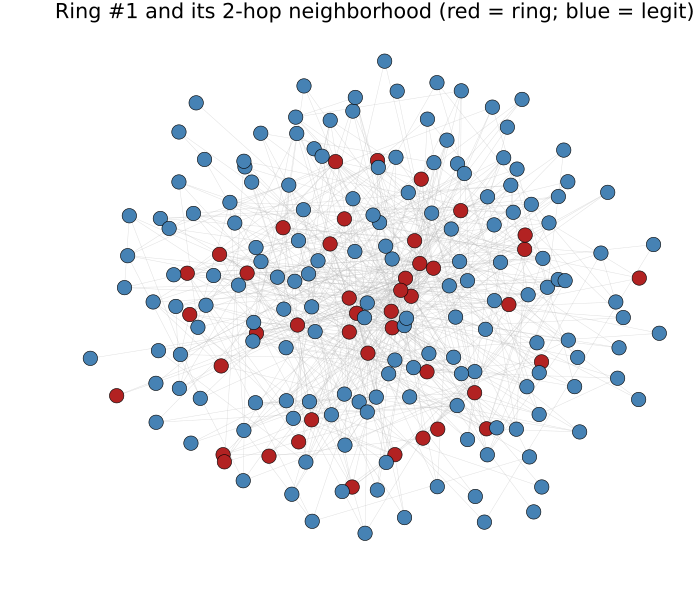

In [4]:
let
    tx_graph = graph_data.tx_graph

    # --- Step 1: Pick one planted ring + its 2-hop neighborhood for visualization ---
    # `ring_id_to_show` selects which planted ring to display. We then collect the
    # ring's member nodes, plus every account those ring members transact with
    # (in either direction), to give the reader the structural context the GNN
    # sees through one round of message passing.
    ring_id_to_show = 1
    ring_nodes = sort([v for (v, r) in tx_graph.ring_membership if r == ring_id_to_show])
    neighbor_set = Set{Int}(ring_nodes)
    for v in ring_nodes
        for u in 1:N_ACCOUNTS
            # Either v -> u or u -> v counts as a transfer, so include u.
            (tx_graph.adjacency[v, u] > 0 || tx_graph.adjacency[u, v] > 0) && push!(neighbor_set, u)
        end
    end
    subgraph_nodes = sort(collect(neighbor_set))
    # Red for ring members (true positives we want to flag), blue for legit.
    node_colors = [tx_graph.labels[v] == 1 ? :firebrick : :steelblue for v in subgraph_nodes]

    # --- Step 2: Compute a 2-D layout via a Fruchterman-Reingold-style force loop ---
    # We need (x, y) coordinates for each node to draw the subgraph. The loop runs
    # a simple force-directed simulation: repulsion between every pair of nodes,
    # attraction along every edge. The result places connected nodes near each
    # other and disconnected nodes apart, so the planted ring appears as a tight
    # red cluster against the surrounding legit accounts.
    g_undirected = SimpleGraph(N_ACCOUNTS)
    for i in 1:N_ACCOUNTS, j in 1:N_ACCOUNTS
        tx_graph.adjacency[i, j] > 0 && add_edge!(g_undirected, i, j)
    end
    # Restrict the layout to the picked ring's neighborhood (faster than laying
    # out all 500 nodes and discarding most).
    subg, vmap = induced_subgraph(g_undirected, subgraph_nodes)
    Random.seed!(MASTER_SEED)
    n = nv(subg)                              # number of nodes in the subgraph
    xs = randn(n); ys = randn(n)              # initial coordinates: standard normal
    for _ in 1:200                            # 200 force-update sweeps is enough for clean separation
        fx = zeros(n); fy = zeros(n)          # accumulated force on each node this sweep
        # Repulsion: every pair pushes apart with strength 1 / distance^2.
        for u in 1:n, v in 1:n
            u == v && continue
            dx = xs[u] - xs[v]; dy = ys[u] - ys[v]
            d2 = dx^2 + dy^2 + 1e-3           # epsilon avoids divide-by-zero on coincident nodes
            fx[u] += dx / d2; fy[u] += dy / d2
        end
        # Attraction: every edge pulls its endpoints together with linear strength.
        for e in edges(subg)
            u = src(e); v = dst(e)
            dx = xs[u] - xs[v]; dy = ys[u] - ys[v]
            fx[u] -= 0.05 * dx; fy[u] -= 0.05 * dy   # u pulled toward v
            fx[v] += 0.05 * dx; fy[v] += 0.05 * dy   # v pulled toward u (Newton's 3rd)
        end
        xs .+= 0.01 .* fx; ys .+= 0.01 .* fy  # small step in the accumulated force direction
    end

    # --- Step 3: Plot subgraph (edges first, then nodes on top) ---
    # We draw edges as thin gray segments, then scatter the nodes over them so the
    # node markers cover edge endpoints. The legend pattern uses label="" to hide
    # the auto-generated entries; the title carries the colour key.
    plt = plot(size=(700, 600), legend=:topright, framestyle=:none,
        title="Ring #$(ring_id_to_show) and its 2-hop neighborhood (red = ring; blue = legit)",
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 4Plots.mm, top_margin = 4Plots.mm)
    for e in edges(subg)
        plot!(plt, [xs[src(e)], xs[dst(e)]], [ys[src(e)], ys[dst(e)]];
            color=:gray70, alpha=0.4, linewidth=0.5, label="")
    end
    scatter!(plt, xs, ys; markercolor=node_colors, markersize=8,
        markerstrokecolor=:black, markerstrokewidth=0.5, label="")
    display(plt)
end;

Each row of the table below is one of the six per-node feature columns from $\mathbf{X}$, with its mean over ring members and its mean over legit accounts side by side. The six features are:

* __in_volume__: total inbound dollar volume into the account
* __out_volume__: total outbound dollar volume from the account
* __n_counterparties__: number of distinct accounts the account transacts with
* __account_age__: account age in days
* __avg_amount__: average per-transfer dollar amount
* __geo_hash__: numeric hash of the account's geographic region

All six are computed from the Erdős–Rényi background transfers only (ring-internal flows are excluded by construction) and then standardized to zero mean and unit variance across the population. The __Gap__ column is the ring-class mean minus the legit-class mean in those same standardized units, so a value near zero means the feature has no class-separating power on its own.

In [5]:
let
    tx_graph = graph_data.tx_graph

    # --- Step 1: Per-class mean of each feature ---
    # node_features is a (6, N) matrix where row r is one of the six summary
    # features (already standardized to zero mean / unit variance across all N
    # accounts). For each row we take the mean over the ring members
    # (labels .== 1) and over the legit accounts (labels .== 0). The Gap column
    # is in standardized units; a value near 0 means the feature has roughly the
    # same mean in both classes and therefore no class-separating power on its
    # own. The generator was tuned so all six gaps are small, which forces the
    # GNN's edge between the two classes to come from graph structure, not
    # from per-node feature columns.
    feature_names = ["in_volume", "out_volume", "n_counterparties", "account_age", "avg_amount", "geo_hash"]
    ring_means  = [round(mean(tx_graph.node_features[r, tx_graph.labels .== 1]); digits=2) for r in 1:6]
    legit_means = [round(mean(tx_graph.node_features[r, tx_graph.labels .== 0]); digits=2) for r in 1:6]

    # --- Step 2: Render the table; Gap column drives the take-away ---
    feature_table = DataFrame(
        Feature        = feature_names,
        var"Ring mean"  = ring_means,
        var"Legit mean" = legit_means,
        var"Gap (σ)"    = round.(ring_means .- legit_means; digits=2),
    )
    pretty_table(feature_table; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically   = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end;

 ------------------ ----------- ------------ ---------
           Feature   Ring mean   Legit mean   Gap (σ) 
            String     Float32      Float32   Float32 
 ------------------ ----------- ------------ ---------
         in_volume        0.02         -0.0      0.02
        out_volume       -0.03         0.01     -0.04
  n_counterparties        0.01         -0.0      0.01
       account_age        0.04        -0.01      0.05
        avg_amount       -0.02          0.0     -0.02
          geo_hash        0.05        -0.01      0.06
 ------------------ ----------- ------------ ---------


Every feature column has nearly identical means in the two classes, with gaps inside the noise floor at this sample size. The volume and counterparty columns, which would naively be the most class-discriminative (laundering rings transact heavily with each other), are explicitly stripped of that signal because the generator computes per-node features only from the Erdős–Rényi background subset of transfers, not from ring-internal flows. The take-away: a feature-only classifier has no signal to learn from; whatever class separation appears in Task 3 has to come from the graph adjacency, not from the columns of $\mathbf{X}$.

___
## Task 2: Build, train, and evaluate the GNN node classifier

In this task, we build the three-layer GraphSAGE-style stack from the Background: each layer applies the self-plus-neighbor update $\mathbf{h}_{i}^{(\ell + 1)} = \sigma(\mathbf{W}_{1}^{(\ell)}\,\mathbf{h}_{i}^{(\ell)} + \mathbf{W}_{2}^{(\ell)}\sum_{j \in \mathcal{N}(i)} \mathbf{h}_{j}^{(\ell)} + \mathbf{b}^{(\ell)})$ with hidden width $d_{\ell} = 32$ at every internal layer and a final 2-logit head per node. The implementation is in [the `MyFraudGNNLayer` struct](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#eCornellAIFinance.MyFraudGNNLayer); it carries separate weights $\mathbf{W}_{1}, \mathbf{W}_{2}$ for the self and neighbor terms and uses a sum aggregator over each node's neighbors.

Training uses class-weighted cross-entropy on the train-mask nodes only; the test-mask nodes' features and edges still flow through message passing, but their labels stay invisible to the loss. After training, we read the predicted class on every node and score it against the held-out labels via [the `evaluate_fraud_classifier(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#eCornellAIFinance.evaluate_fraud_classifier), which returns a confusion matrix in the named tuple `(tp, fp, fn, tn)`. The training cell binds `gnn_run::NamedTuple` (with fields `history`, `metrics_train`, and `metrics_test`); the cells that follow render the per-split confusion-matrix tables with precision, recall, F1, and accuracy.

In [6]:
gnn_run = let
    tx_graph  = graph_data.tx_graph
    gnn_graph = graph_data.gnn_graph

    # --- Step 1: Build a fresh GNN with default weight initialization ---
    # The model is a three-layer GraphSAGE-style stack with hidden width
    # N_HIDDEN = 32 and an output head that emits N_CLASSES = 2 logits per node
    # (one per class). Reseeding here makes the initial weights reproducible.
    Random.seed!(MASTER_SEED)
    gnn_model = build_fraud_gnn(
        nin       = size(tx_graph.node_features, 1),   # input feature dim (= 6)
        nh        = N_HIDDEN,                          # hidden width per message-passing layer
        nout      = N_CLASSES,                         # output dim (2: ring vs legit)
        dropout_p = DROPOUT_P,                         # 0.2 lightly regularizes; closes the train/test F1 gap
    )

    # --- Step 2: Train with weighted cross-entropy on the train mask ---
    # The loss is summed over labeled nodes only (those with train_mask == true);
    # test-mask features and edges still flow through message passing so the
    # network gets the full graph context, but test labels never enter the loss.
    # Class weights [1.0, 5.0] up-weight ring members by 5x to compensate for the
    # ~15% positive rate; without that, the loss would prefer "all legit" trivially.
    history = train_fraud_gnn!(gnn_model, gnn_graph, tx_graph.labels,
        tx_graph.train_mask, tx_graph.test_mask;
        n_classes     = N_CLASSES,
        epochs        = EPOCHS,
        η             = LEARNING_RATE,                # Adam step size
        class_weights = CLASS_WEIGHTS,                # [1.0, 5.0] Float32
        infotime      = INFOTIME,                     # log every 50 epochs to history
    )
    # `history::NamedTuple` carries: .epochs (logged epoch numbers),
    # .train_losses and .test_losses (loss at each logged epoch), .train_f1 and
    # .test_f1 (F1 at each logged epoch). We use .train_losses below for the
    # GNN-vs-MLP loss-curve overlay.

    # --- Step 3: Predict on every node, then score the train and test masks ---
    # The model returns an (N_CLASSES, N) logits matrix. Flux.onecold picks the
    # argmax row per column (1 or 2), and we subtract 1 to map back to {0, 1}
    # = {legit, ring}. We then score the prediction on each mask separately so
    # the train and test confusion matrices can be displayed side by side.
    gnn_logits = gnn_model(gnn_graph, gnn_graph.ndata.x)
    gnn_preds  = Flux.onecold(gnn_logits) .- 1
    metrics_train = evaluate_fraud_classifier(gnn_preds, tx_graph.labels, tx_graph.train_mask)
    metrics_test  = evaluate_fraud_classifier(gnn_preds, tx_graph.labels, tx_graph.test_mask)
    println("Trained ", EPOCHS, " epochs; predicted classes on all ", length(gnn_preds), " nodes.")

    # Returned tuple: history for the loss curve; per-split metrics for the
    # confusion matrices and the GNN vs MLP scorecard.
    (history = history, metrics_train = metrics_train, metrics_test = metrics_test)
end;

Trained 300 epochs; predicted classes on all 1000 nodes.


### Error analysis

Total error rate hides the false-positive / false-negative trade-off. The __confusion matrix__ breaks predictions into true positives (TP), false positives (FP), false negatives (FN), and true negatives (TN); from these we report precision $= TP / (TP + FP)$, recall $= TP / (TP + FN)$, and $F_{1} = 2\,P\,R / (P + R)$ on the fraud (ring-member) class. Under heavy imbalance, $F_{1}$ on the minority class is the metric that survives: a classifier that always predicts _legit_ achieves high accuracy while catching zero ring members.

Let's start with the training set:

In [7]:
let
    metrics  = gnn_run.metrics_train     # scorecard NamedTuple for the train split
    cm_train = metrics.confusion         # (tp, fp, fn, tn) NamedTuple of counts

    # --- Train confusion matrix: rows = Actual class, columns = Predicted class ---
    # Top row is actually-Legit accounts (tn under "Pred Legit", fp under "Pred Fraud").
    # Bottom row is actually-Fraud accounts (fn under "Pred Legit", tp under "Pred Fraud").
    # A clean classifier has the off-diagonal cells near zero.
    train_confusion_table = DataFrame(
        Actual          = ["Legit", "Fraud"],
        var"Pred Legit" = [cm_train.tn, cm_train.fn],
        var"Pred Fraud" = [cm_train.fp, cm_train.tp],
    )
    pretty_table(train_confusion_table; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically   = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # Precision (P), recall (R), F1, and accuracy are computed on the fraud class.
    # F1 = 2 P R / (P + R) is the most informative under heavy imbalance.
    println("Train: P=", round(metrics.precision, digits=3),
            "  R=",     round(metrics.recall,    digits=3),
            "  F1=",    round(metrics.f1,        digits=3),
            "  acc=",   round(metrics.accuracy,  digits=3))
end;

 -------- ------------ ------------
  Actual   Pred Legit   Pred Fraud 
  String        Int64        Int64 
 -------- ------------ ------------
   Legit          549           39
   Fraud           11          101
 -------- ------------ ------------
Train: P=0.721  R=0.902  F1=0.802  acc=0.929


Now, how about the test set (we have never seen these examples during training)?

In [8]:
let
    metrics = gnn_run.metrics_test       # scorecard for the held-out split
    cm_test = metrics.confusion          # (tp, fp, fn, tn) counts on test nodes only

    # --- Test confusion matrix: same layout as the train table above ---
    # The test mask covers nodes the loss never saw (their labels were hidden
    # during training). The gap between train and test F1 measures generalization.
    test_confusion_table = DataFrame(
        Actual          = ["Legit", "Fraud"],
        var"Pred Legit" = [cm_test.tn, cm_test.fn],
        var"Pred Fraud" = [cm_test.fp, cm_test.tp],
    )
    pretty_table(test_confusion_table; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically   = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    println("Test:  P=", round(metrics.precision, digits=3),
            "  R=",     round(metrics.recall,    digits=3),
            "  F1=",    round(metrics.f1,        digits=3),
            "  acc=",   round(metrics.accuracy,  digits=3))
end;

 -------- ------------ ------------
  Actual   Pred Legit   Pred Fraud 
  String        Int64        Int64 
 -------- ------------ ------------
   Legit          229           23
   Fraud            5           43
 -------- ------------ ------------
Test:  P=0.652  R=0.896  F1=0.754  acc=0.907


___
## Task 3: Quantify the value of graph structure

In this task, we hold the node features and the masks fixed and replace the GNN with a flat multi-layer perceptron (MLP) that has the same input dimension, the same hidden width, and the same number of parameters per layer, but no message passing. The MLP is the strongest possible features-only baseline: it is given exactly the same training signal the GNN was given, but it cannot see the adjacency matrix and so has to predict ring membership from each account's six standardized summary features alone. The training loop and class weighting are the same as the GNN's so any score difference is attributable to the architecture, not the optimization.

The code block below trains the MLP and prints a side-by-side scorecard (precision, recall, F1, accuracy on the test mask). Because the generator was tuned so that ring and legit accounts have nearly identical mean features (Task 1), the gap between the two columns in the scorecard is the value the graph adds.

In [9]:
let
    tx_graph         = graph_data.tx_graph
    gnn_metrics_test = gnn_run.metrics_test

    # --- Step 1: Build a feature-only MLP with matched depth/width ---
    # Three Dense layers with the same hidden width as the GNN's message-passing
    # stages, ending in a 2-logit output head. The MLP sees `node_features` only;
    # it has no access to the adjacency matrix, so any structural signal in the
    # graph is invisible to it. Reseeding here makes the comparison reproducible.
    Random.seed!(MASTER_SEED)
    mlp_model = Chain(
        Dense(size(tx_graph.node_features, 1), N_HIDDEN, relu),    # 6 -> 32, ReLU
        Dense(N_HIDDEN, N_HIDDEN, relu),                            # 32 -> 32, ReLU
        Dense(N_HIDDEN, N_CLASSES),                                 # 32 -> 2 logits
    )

    # --- Step 2: Train with masked weighted cross-entropy (no graph) ---
    # `train_idx`: column indices of train-mask nodes (a Vector{Int}) so we can
    # restrict the loss to them inside the gradient closure.
    train_idx = findall(tx_graph.train_mask)
    # `y_onehot`: (2, N) one-hot encoding of the labels. Row 1 is class 0 (legit),
    # row 2 is class 1 (ring). We use +1 to shift Julia's 1-based row index.
    y_onehot  = zeros(Float32, N_CLASSES, N_ACCOUNTS)
    for i in 1:N_ACCOUNTS
        y_onehot[tx_graph.labels[i] + 1, i] = 1.0f0
    end
    # `w_train`: per-train-node weight, 1.0 for legit and 5.0 for ring, so the
    # loss matches the class-weighted cross-entropy used by the GNN trainer.
    w_train = Float32[CLASS_WEIGHTS[tx_graph.labels[i] + 1] for i in train_idx]
    opt_state = Flux.setup(Adam(LEARNING_RATE), mlp_model)

    # Training loop. At each epoch, compute the gradient of the weighted
    # cross-entropy restricted to the train mask, then take an Adam step.
    for epoch in 1:EPOCHS
        grads = Flux.gradient(mlp_model) do m
            ŷ_sub = m(tx_graph.node_features)[:, train_idx]         # (2, |train|) logits on train nodes
            y_sub = y_onehot[:, train_idx]                          # (2, |train|) one-hot labels
            logp  = Flux.logsoftmax(ŷ_sub; dims = 1)                # log-probabilities per node
            # Weighted negative log-likelihood: sum over train nodes of
            # w_i * (-log p_i[true class]). Reshape w to (1, |train|) so the
            # broadcast multiplies one weight per column.
            -sum(reshape(w_train, 1, :) .* (y_sub .* logp)) / sum(w_train)
        end
        Flux.Optimise.update!(opt_state, mlp_model, grads[1])
    end

    # --- Step 3: Score the MLP on the same test mask ---
    # Pick the argmax class per node, map {1, 2} back to {0, 1}, and score
    # against the held-out labels using the same evaluator as the GNN.
    mlp_preds   = Flux.onecold(mlp_model(tx_graph.node_features)) .- 1
    mlp_metrics = evaluate_fraud_classifier(mlp_preds, tx_graph.labels, tx_graph.test_mask)

    # --- Step 4: Side-by-side test scorecard ---
    # One row per metric, two columns: the GNN (which used edges) and the MLP
    # (which used only features). The F1 gap between the two columns is the
    # value of graph structure in this task.
    comparison = DataFrame(
        Metric             = ["Precision (fraud)", "Recall (fraud)", "F1 (fraud)", "Accuracy (overall)",
                              "True positives", "False positives", "False negatives", "True negatives"],
        var"GNN (with graph)"  = [round(gnn_metrics_test.precision, digits=3),
                                  round(gnn_metrics_test.recall,    digits=3),
                                  round(gnn_metrics_test.f1,        digits=3),
                                  round(gnn_metrics_test.accuracy,  digits=3),
                                  gnn_metrics_test.confusion.tp, gnn_metrics_test.confusion.fp,
                                  gnn_metrics_test.confusion.fn, gnn_metrics_test.confusion.tn],
        var"MLP (features only)" = [round(mlp_metrics.precision, digits=3),
                                     round(mlp_metrics.recall,    digits=3),
                                     round(mlp_metrics.f1,        digits=3),
                                     round(mlp_metrics.accuracy,  digits=3),
                                     mlp_metrics.confusion.tp, mlp_metrics.confusion.fp,
                                     mlp_metrics.confusion.fn, mlp_metrics.confusion.tn],
    )
    pretty_table(comparison; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically   = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end;

 -------------------- ------------------ ---------------------
              Metric   GNN (with graph)   MLP (features only) 
              String            Float64               Float64 
 -------------------- ------------------ ---------------------
   Precision (fraud)              0.652                 0.118
      Recall (fraud)              0.896                 0.125
          F1 (fraud)              0.754                 0.121
  Accuracy (overall)              0.907                  0.71
      True positives               43.0                   6.0
     False positives               23.0                  45.0
     False negatives                5.0                  42.0
      True negatives              229.0                 207.0
 -------------------- ------------------ ---------------------


Both models trained on the same node features, the same train / test mask, the same class weights, and the same Adam schedule; only the GNN sees the adjacency. The MLP's precision lands near the base fraud rate, the signature of a model flagging at random: by construction (Task 1) the features carry no class signal, so no tabular classifier can recover one. The GNN, looking at the same features through three rounds of neighborhood aggregation, lifts $F_{1}$ by a wide margin; the lift comes entirely from the planted-ring topology in the adjacency, which message passing makes visible to the per-node head.

___
## Summary

We generated a synthetic AML transaction graph with planted laundering rings, trained a three-layer GraphSAGE-style GNN to classify each account as ring member or legitimate, and compared it against a flat-features MLP trained on the same inputs.

> __Key Takeaways:__
>
> * __Money-laundering detection is naturally a graph problem when laundering has graph structure:__ Planted laundering rings have a multi-hop topology that a flat tabular classifier cannot see. The GNN trains on the same labeled subset of nodes that an MLP would, but its message-passing layers also use every node's features and edges through the adjacency matrix.
> * __F1 on the minority class is the metric that matters under imbalance:__ When only a small fraction of accounts are ring members, a model that always predicts _legit_ still hits high accuracy while catching zero ring members. Class-weighted cross-entropy keeps the loss honest, and precision / recall / F1 on the laundering-ring class is what gets reported to the compliance team.
> * __Graph structure adds value precisely when the features are weak:__ The generator was tuned so per-node features overlap heavily across the two classes, making this a hard task for a feature-only classifier. The wide $F_{1}$ gap between the GNN and the MLP on the test mask isolates the value of message passing on this graph.

The GNN exploits two-hop neighborhood structure to identify the rings cleanly while the MLP, forced to rely on noisy per-account summary features alone, lands meaningfully behind on F1.

### Disclaimer

This content is for educational purposes only and does not constitute investment advice. The transaction graph is synthetic and the laundering rings are planted by the generator; real-world AML deployment requires additional regulatory, legal, and operational controls beyond what this notebook demonstrates.

___